# 03 · Evaluate the frozen model and interpret associations

        **Question:** How well do the relationships generalize, where do predictions fail,
        and which associations are stable enough to discuss?

        This walkthrough recomputes metrics from saved predictions, draws diagnostics,
        and checks that the published findings match the evidence. Optional refitting
        uses the already-selected specification. All 2024 analyses here are reporting
        diagnostics; none changes model selection.

        [Dataset](01_modeling_dataset.ipynb) · [Training](02_training_and_validation.ipynb) · [Setup](README.md)

In [1]:
from pathlib import Path
import sys, json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Works from the notebook directory or the source/bundle root.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "src/modeling/county_characteristics.py").exists())
sys.path.insert(0, str(ROOT))
NB_DIR = ROOT / "notebooks/03_modeling"
EVIDENCE = NB_DIR / "evidence"
def read_csv(name):
    return pd.read_csv(EVIDENCE / name, dtype={"county_fips": str})
def read_json(name):
    return json.loads((EVIDENCE / name).read_text(encoding="utf-8"))

# Fail loudly if a packaged artifact has changed since publication.
provenance = read_json("snapshot.json")
for name, digest in provenance["sha256"].items():
    assert hashlib.sha256((EVIDENCE / name).read_bytes()).hexdigest() == digest, name
panel = pd.read_parquet(EVIDENCE / "county_period_panel.parquet")
manifest = read_csv("feature_manifest.csv")
groups = {group: data.feature.tolist() for group, data in
          manifest.loc[manifest.role.eq("primary")].groupby("group")}
features = [feature for columns in groups.values() for feature in columns]
from src.modeling.county_price import TARGET, regression_metrics
plt.rcParams.update({"figure.figsize": (9, 4), "axes.spines.top": False,
                     "axes.spines.right": False, "figure.dpi": 110})
pd.set_option("display.max_colwidth", 90)
print("Evidence: completed full study, 2026-10-06; equal county-period weights.")

Evidence: completed full study, 2026-10-06; equal county-period weights.


## 1. Recompute held-out metrics

        Refit the frozen family winners on 2014 + 2019; evaluate 2024. The baseline now
        uses the median of those same development rows. MAE and R² use dollars; RMSLE
        uses differences in `log1p` dollar values (distinct from the natural-log training target).
        All models are compared on the identical 3,139 counties.

In [2]:
selection = read_json("selection.json")
predictions = read_csv("test_predictions.csv")
saved_metrics = read_csv("test_metrics.csv")
assert predictions.year.eq(2024).all() and predictions.county_fips.is_unique
np.testing.assert_allclose(predictions.selected_prediction, predictions[selection["selected"]])
metrics = pd.DataFrame([{"model": name, **regression_metrics(predictions[TARGET], predictions[name])}
                        for name in saved_metrics.model])
pd.testing.assert_frame_equal(metrics, saved_metrics, check_exact=False, rtol=1e-10)
display(metrics.round(4))
indexed = metrics.set_index("model")
chosen = indexed.loc[selection["selected"]]
improvement = 1 - chosen.rmsle / indexed.loc["training_median", "rmsle"]
print(f"Selected model: R² {chosen.r2:.3f}; MAE ${chosen.mae_2024_usd:,.0f}; RMSLE improvement {improvement:.1%}")

,model,rmsle,mae_2024_usd,median_ape,r2
0,training_median,0.5731,97193.5626,0.3213,-0.2798
1,hist_direct_2,0.2093,37197.9447,0.1240,0.8009
2,extra_trees_1,0.2165,38471.0761,0.1276,0.7936
3,elastic_net_2,0.2180,38249.6439,0.1307,0.8092


Selected model: R² 0.801; MAE $37,198; RMSLE improvement 63.5%


## 2. Optional refit, with the choice already frozen

        This code calls the shared training pipeline. It never searches over 2024 results.
        The check compares a fresh development fit with published predictions. Minor
        numerical differences across software versions can occur; use the recorded environment.

In [3]:
REFIT_SELECTED = False
if REFIT_SELECTED:
    from threadpoolctl import threadpool_limits
    from src.modeling.county_characteristics import study_candidates, fit_model, value_prediction
    development = panel.loc[panel.year.lt(2024)]
    test = panel.loc[panel.year.eq(2024)]
    if selection["selected"] == "training_median":
        predicted = np.full(len(test), development[TARGET].median())
    else:
        candidate = next(c for c in study_candidates() if c.name == selection["selected"])
        with threadpool_limits(limits=2):
            model = fit_model(candidate, development, features)
            predicted = value_prediction(model, test, features)
    saved = predictions.set_index("county_fips").loc[test.county_fips, "selected_prediction"]
    np.testing.assert_allclose(predicted, saved, rtol=1e-6)
    print("Refitted predictions match the study.")
else:
    print("Metrics recomputed from saved predictions; refit is optional.")

Metrics recomputed from saved predictions; refit is optional.


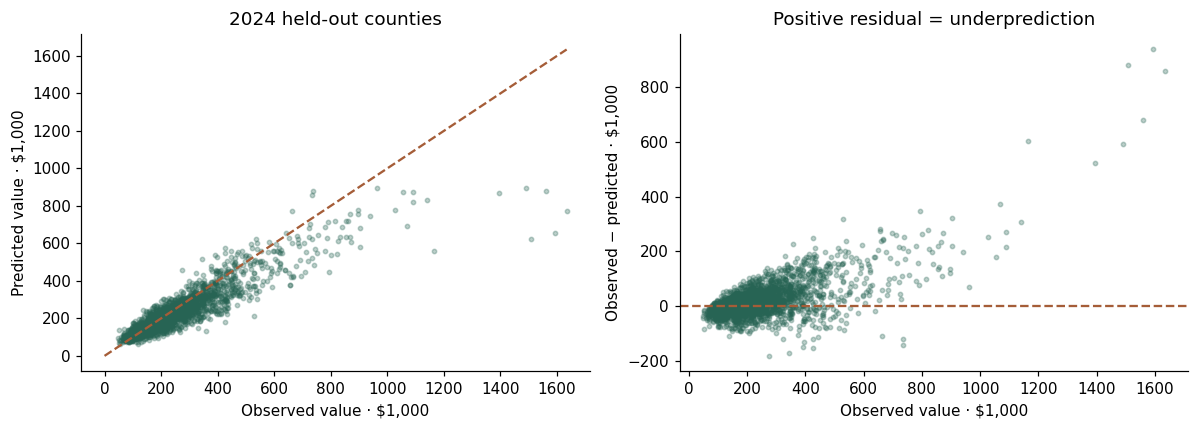

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(predictions[TARGET] / 1000, predictions.selected_prediction / 1000,
                s=8, alpha=.3, color="#276454")
limit = max(predictions[TARGET].max(), predictions.selected_prediction.max()) / 1000
axes[0].plot([0, limit], [0, limit], "--", color="#a55d38")
axes[0].set(xlabel="Observed value · $1,000", ylabel="Predicted value · $1,000", title="2024 held-out counties")
axes[1].scatter(predictions[TARGET] / 1000, predictions.residual_usd / 1000,
                s=8, alpha=.3, color="#276454")
axes[1].axhline(0, color="#a55d38", linestyle="--")
axes[1].set(xlabel="Observed value · $1,000", ylabel="Observed − predicted · $1,000", title="Positive residual = underprediction")
plt.tight_layout(); plt.show()

## 3. Find where the model is less reliable

        State, metro status and observed-value deciles describe errors; they were not used
        to select a model. Small state samples can make R² unstable. Dollar errors usually
        grow with the scale of home values, so inspect proportional errors too. Deciles use
        observed 2024 outcomes and are diagnostic groups, not deployable inputs.

,dimension,value,rows,rmsle,mae_2024_usd,median_ape,r2
11,state,HI,4,0.247207,166088.027580,0.188623,-0.309626
4,state,CA,58,0.372432,166061.841283,0.273187,0.500044
19,state,MA,14,0.339174,161392.258802,0.148139,0.219060
7,state,DC,1,0.176625,142395.902648,0.193184,NaN
44,state,UT,29,0.423154,136627.817915,0.320771,0.264943
13,state,ID,44,0.466444,123474.973456,0.356801,-0.231106
47,state,WA,39,0.349005,118337.136941,0.291584,0.120331
37,state,OR,36,0.369630,112684.832292,0.305726,0.020758
5,state,CO,64,0.316104,103772.248469,0.237098,0.700914
50,state,WY,23,0.323086,96818.408953,0.190812,0.528942


,dimension,value,rows,rmsle,mae_2024_usd,median_ape,r2
51,msa_type,Metro,1158,0.190249,43847.309232,0.110178,0.799915
52,msa_type,Micro,639,0.200867,36969.437340,0.120819,0.759359
53,msa_type,Nonmetro,1333,0.228590,31490.940626,0.140623,0.682851
54,msa_type,Unknown,9,0.139122,43141.101302,0.144218,0.775405


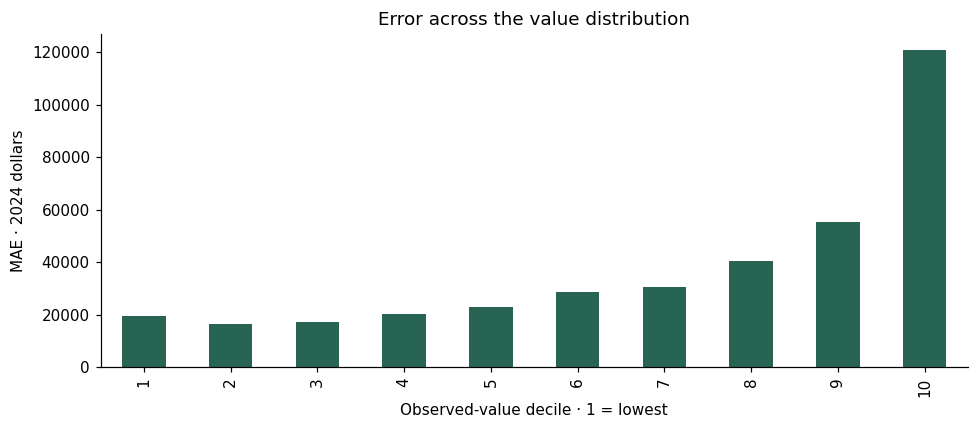

In [5]:
breakdowns = read_csv("error_breakdowns.csv")
display(breakdowns.loc[breakdowns.dimension.eq("state")].sort_values("mae_2024_usd", ascending=False).head(10))
display(breakdowns.loc[breakdowns.dimension.eq("msa_type")])
deciles = breakdowns.loc[breakdowns.dimension.eq("value_decile")].copy()
deciles["decile"] = deciles.value.astype(int) + 1
ax = deciles.plot.bar(x="decile", y="mae_2024_usd", color="#276454", legend=False)
ax.set(xlabel="Observed-value decile · 1 = lowest", ylabel="MAE · 2024 dollars", title="Error across the value distribution")
plt.tight_layout(); plt.show()

## 4. Test feature groups on identical rows

        Removing one group at a time asks how much predictive information the remaining
        groups can recover under the fixed model specification. It is not a causal test.
        Affordability and climate sensitivities stay separate; climate comparisons use
        only their matched covered counties.

In [6]:
experiments = read_csv("feature_group_experiments.csv")
primary = experiments.loc[experiments.experiment.eq("all_primary") | experiments.experiment.str.startswith("without_")].copy()
assert primary.rows.nunique() == 1
base = primary.loc[primary.experiment.eq("all_primary"), "rmsle"].iloc[0]
primary["rmsle_change_pct"] = 100 * (primary.rmsle / base - 1)
display(primary[["experiment", "rows", "rmsle", "rmsle_change_pct"]].round(3))
display(experiments.loc[experiments.experiment.str.startswith(("climate_", "affordability_"))])

,experiment,rows,rmsle,rmsle_change_pct
0,without_economic,3139,0.261,24.617
1,without_hazards,3139,0.212,1.156
2,without_housing,3139,0.217,3.739
3,without_social,3139,0.214,2.055
4,all_primary,3139,0.209,0.000


,experiment,rows,rmsle,mae_2024_usd,median_ape,r2
5,affordability_matched_primary,3139,0.209311,37197.944669,0.123977,0.800851
6,affordability_augmented,3139,0.203993,36460.803234,0.125712,0.816191
7,climate_matched_primary,1594,0.216829,38194.022424,0.135086,0.804453
8,climate_augmented,1594,0.212863,37920.825131,0.134244,0.808458


Removing the economic group raises RMSLE by about **24.6%**, the largest increase
        among the primary groups. Correlated social and housing features can substitute
        for some economic information, so this does not allocate unique causal contributions.

## 5. Compare linear coefficients and grouped permutation importance

        Coefficients are from the standardized development-fit Elastic Net. They are
        conditional associations in log target units per transformed-feature standard
        deviation, not dollar effects. Group permutation shuffles related columns
        together and measures the increase in held-out RMSLE. The repeat spread measures
        permutation variability, not sampling uncertainty.

In [7]:
coefficients = read_csv("standardized_coefficients.csv")
top = coefficients.loc[~coefficients.feature.str.contains("missingindicator")].nlargest(12, "absolute_coefficient")
display(top)
importance = read_csv("group_permutation.csv")
display(importance.groupby(["group", "model"]).rmsle_increase.agg(["mean", "std"]).round(4))
stability = read_csv("coefficient_stability.csv")
display(stability.loc[stability.feature.isin(top.feature.head(6))].pivot(index="feature", columns="year", values="coefficient").round(4))

,feature,coefficient,absolute_coefficient
0,numeric__log1p__median_household_income_2024_usd,0.160854,0.160854
1,numeric__bachelors_degree_or_higher_pct,0.118672,0.118672
2,numeric__average_family_size,-0.064308,0.064308
3,numeric__average_owner_household_size,0.063338,0.063338
4,numeric__built_1939_or_earlier_pct,-0.058414,0.058414
5,numeric__owner_occupied_pct,-0.051536,0.051536
6,numeric__log1p__housing_units,0.048573,0.048573
7,numeric__households_with_children_pct,-0.048305,0.048305
8,numeric__agriculture_mining_industry_pct,-0.046941,0.046941
9,numeric__log1p__period_sum__storm_event_count,-0.042956,0.042956


mean     std
group    model                        
economic elastic_net_2  0.2507  0.0038
         extra_trees_1  0.2792  0.0026
         hist_direct_2  0.2811  0.0037
hazards  elastic_net_2  0.0145  0.0012
         extra_trees_1  0.0066  0.0005
         hist_direct_2  0.0116  0.0010
housing  elastic_net_2  0.0918  0.0016
         extra_trees_1  0.0322  0.0006
         hist_direct_2  0.0452  0.0018
social   elastic_net_2  0.1103  0.0016
         extra_trees_1  0.0679  0.0019
         hist_direct_2  0.0745  0.0018

year,2014,2019,2024
feature,,,
numeric__average_family_size,-0.0559,-0.0484,-0.0554
numeric__average_owner_household_size,0.0640,0.0560,0.0719
numeric__bachelors_degree_or_higher_pct,0.1262,0.0963,0.0745
numeric__built_1939_or_earlier_pct,-0.0574,-0.0748,-0.0750
numeric__log1p__median_household_income_2024_usd,0.1497,0.1683,0.1657
numeric__owner_occupied_pct,-0.0694,-0.0685,-0.0694


Income and educational attainment are positive associations in the reported
        study; vacancy is negative. Coefficient magnitudes need caution when predictors
        overlap. Period-specific fits are descriptive checks, including 2024, and never
        feed back into model selection. Inspect changes in sign and magnitude rather
        than presenting any one ranking as definitive.

## 6. Restrict response curves to supported ranges

        The study's accumulated local log effects use development-derived bins within
        the 5th–95th percentiles. Each displayed bin contains at least 20 test counties.
        Differences compare bin-edge predictions only for counties inside that bin.
        Missing bins are not interpolated. These model responses are not interventions.

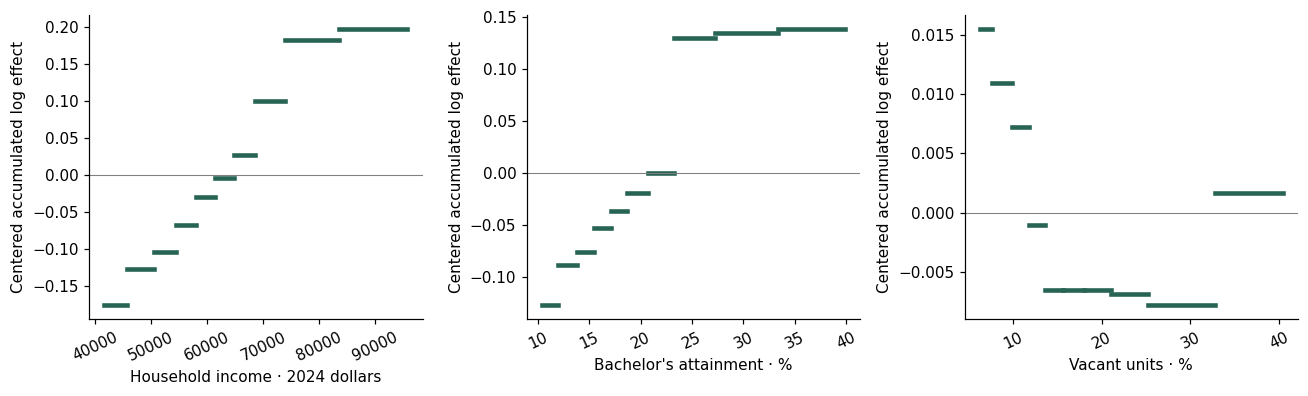

,bins,smallest_bin
feature,,
bachelors_degree_or_higher_pct,10,60
log1p__median_household_income_2024_usd,10,98
vacant_housing_units_pct,10,120


In [8]:
curves = read_csv("local_response_curves.csv")
assert curves.rows.ge(20).all()
fig, axes = plt.subplots(1, 3, figsize=(12, 3.7))
labels = ["Household income · 2024 dollars", "Bachelor's attainment · %", "Vacant units · %"]
for ax, (feature, group), label in zip(axes, curves.groupby("feature", sort=False), labels):
    for row in group.itertuples():
        x = np.array([row.left, row.right])
        if feature.startswith("log1p__"):
            x = np.expm1(x)
        ax.plot(x, [row.accumulated_log_effect] * 2, color="#276454", linewidth=3)
    ax.axhline(0, color="gray", linewidth=.7)
    ax.set(xlabel=label, ylabel="Centered accumulated log effect")
    ax.tick_params(axis="x", rotation=25)
plt.tight_layout(); plt.show()
display(curves.groupby("feature").agg(bins=("rows", "size"), smallest_bin=("rows", "min")))

## 7. Keep the secondary questions distinct

        County-and-period fixed effects study changes within stable counties. Their
        within R² has a different denominator than the cross-county prediction R².
        Intervals use county-clustered uncertainty. The annual forecast experiment
        predicts the next ACS estimate; overlapping survey windows and unreconstructed
        release/CPI vintages prevent an operational forecasting claim.
        These saved summaries provide context; full implementation is in
        `src/modeling/county_characteristics.py` and [COUNTY_STUDY.md](../../COUNTY_STUDY.md).

In [9]:
display(pd.Series(read_json("fixed_effects_summary.json")))
display(read_csv("fixed_effects.csv"))
display(read_csv("forecast_metrics.csv"))

rows                                                                                                  9363
counties                                                                                              3121
within_r2                                                                                          0.13205
excluded_rows                                                                                           57
features         [log1p__median_household_income_2024_usd, bachelors_degree_or_higher_pct, vacant_housi...
uncertainty                County-clustered t intervals; not spatially clustered; no causal identification
dtype: object

,feature,coefficient,cluster_se,ci_low,ci_high,p_value,interpretation
0,log1p__median_household_income_2024_usd,0.392314,0.034617,0.324441,0.460188,3.323224e-29,Log outcome per one predictor unit; income predictor is log1p dollars
1,bachelors_degree_or_higher_pct,0.006153,0.001048,0.004097,0.008208,4.837020e-09,Log outcome per one predictor unit; income predictor is log1p dollars
2,vacant_housing_units_pct,-0.004826,0.001042,-0.006869,-0.002783,3.788470e-06,Log outcome per one predictor unit; income predictor is log1p dollars
3,detached_single_unit_pct,0.001560,0.000922,-0.000247,0.003367,9.066140e-02,Log outcome per one predictor unit; income predictor is log1p dollars
4,mean_commute_time_minutes,0.001585,0.001171,-0.000711,0.003882,1.759087e-01,Log outcome per one predictor unit; income predictor is log1p dollars
5,average_household_size,0.102085,0.028669,0.045873,0.158297,3.752545e-04,Log outcome per one predictor unit; income predictor is log1p dollars


,design,year,rows,rmsle,mae_2024_usd,median_ape,r2
0,previous_value,all,6240,0.066894,10954.867859,0.042203,0.987740
1,previous_value,2023,3121,0.064566,10175.678723,0.039552,0.988547
2,previous_value,2024,3119,0.069145,11734.556635,0.045335,0.986975
3,history_only,all,6240,0.056238,7718.775821,0.027691,0.992934
4,history_only,2023,3121,0.056013,7350.416607,0.026477,0.993061
5,history_only,2024,3119,0.056462,8087.371239,0.028568,0.992801
6,history_plus_characteristics,all,6240,0.054673,7537.894498,0.025952,0.992776
7,history_plus_characteristics,2023,3121,0.054829,7330.890506,0.025789,0.992865
8,history_plus_characteristics,2024,3119,0.054516,7745.031227,0.026297,0.992677


## What the evidence supports

        Characteristics explain a substantial share of **between-county** variation:
        the selected model reaches 2024 R² **0.801**, MAE **$37,198**, and **63.5%** lower
        RMSLE than the training median. Economic information contributes the largest
        ablation difference. Within-county and next-release analyses answer separate
        questions and offer more modest results.

        The design does not identify causality, individual-home prices, or spatially
        independent effects. ACS smoothing and sampling uncertainty, boundary changes,
        correlated features and incomplete climate coverage constrain interpretation.

        [Return to the interactive study](https://kennethlow.com/housing-predict/)